In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/bondora-final-final/y_test.csv
/kaggle/input/bondora-final-final/X_test.csv
/kaggle/input/bondora-final-final/y_train.csv
/kaggle/input/bondora-final-final/X_train.csv
/kaggle/input/bondora-final/y_test.csv
/kaggle/input/bondora-final/X_test.csv
/kaggle/input/bondora-final/y_train.csv
/kaggle/input/bondora-final/X_train.csv


In [2]:
# !pip uninstall -y scikit-learn
# !pip install scikit-learn==1.4.2
!pip install scikeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 80.2 MB/s eta 0:00:00:00:01:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.6.1 which is incompatible.


In [3]:
X_train = pd.read_csv('/kaggle/input/bondora-final-final/X_train.csv')
y_train = pd.read_csv('/kaggle/input/bondora-final-final/y_train.csv')
X_test = pd.read_csv('/kaggle/input/bondora-final-final/X_test.csv')
y_test = pd.read_csv('/kaggle/input/bondora-final-final/y_test.csv')

In [4]:
X_train.head()

,BidsPortfolioManager,BidsApi,BidsManual,UserName,NewCreditCustomer,Age,Gender,AppliedAmount,Amount,Interest,...,MonthlyPaymentDay,Restructured,NoOfPreviousLoansBeforeLoan,AmountOfPreviousLoansBeforeLoan,PreviousEarlyRepaymentsCountBeforeLoan,MaturityDifference,LastMaturity_LastPaymentOn,LastMaturity_FirstPaymentDate,Rating_Encoded,Dayssincepreviousloan
0,-0.489696,-0.316462,-0.466274,-inline-,0.762821,0.020514,-0.669245,-0.881869,-0.898452,-0.440458,...,-0.590748,-0.50184,-0.624732,-0.585641,-0.214383,0.218546,-1.173360,-1.370206,0.280870,-0.420546
1,-0.926472,-0.316462,-0.277024,-kiisuke-,0.762821,0.020514,0.934364,-1.070404,-1.119692,-0.337601,...,-0.863566,-0.50184,-0.624732,-0.585641,-0.214383,0.218546,-1.208873,-1.659358,-0.927473,-0.420546
2,-0.926472,-0.316462,-0.382606,-kiisuke-,-1.310924,0.020514,0.934364,-1.102077,-1.156833,0.073825,...,-0.863566,-0.50184,0.045080,-0.482513,-0.214383,0.218546,-0.859007,-1.365360,-0.927473,0.727766
3,-0.926472,-0.316462,-0.414281,-kiisuke-,-1.310924,0.020514,0.934364,-1.111579,-1.168043,0.073825,...,-0.863566,-0.50184,0.714891,-0.399996,-0.214383,0.218546,-0.815602,-1.365360,-0.927473,-0.337032
4,-0.926472,-0.316462,0.847065,-party-power-,0.762821,0.020514,-0.669245,-0.733199,-0.723991,0.269766,...,-0.181522,-0.50184,-0.624732,-0.585641,-0.214383,0.218546,-1.053669,-1.660974,-0.927473,-0.420546


In [8]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout, Multiply, Lambda, Add
from keras.layers import Dense, Reshape, Permute
import keras
from keras.models import Model
from keras import layers
from keras.layers import Permute, Reshape, Dense, Masking, LSTM, multiply, Dropout, Input
from keras.preprocessing.sequence import pad_sequences
from keras.callbacks import EarlyStopping
import numpy as np
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

# LSTM_attention
# ===================== 1. DATA PROCESSING =====================
def preprocess_sequential_data(sequences, pad_value=-999, maxlen=6):
    return pad_sequences(sequences, padding='post', dtype='float32', value=pad_value, maxlen=maxlen)


def process_user_sequences(data, user_column, pad_value=-999, maxlen=6):

    if user_column not in data.columns:
        raise ValueError(f"Column `{user_column}` not found in data!")

    # Select numeric columns (excluding user_column if it's numeric)
    numeric_columns = data.select_dtypes(include=['float32', 'float64']).columns
    if user_column in numeric_columns:
        numeric_columns = numeric_columns.drop(user_column)

    sequences = []

    grouped = data.groupby(user_column, sort=False)  # giữ đúng thứ tự gốc

    for _, group in grouped:
        features = group[numeric_columns].values
        for i in range(1, len(features) + 1):
            sequences.append(features[:i])  # growing window

    padded_sequences = pad_sequences(sequences, maxlen=maxlen, padding='post',
                                     dtype='float32', value=pad_value)
    # print(padded_sequences.shape)
    # print(padded_sequences[2])
    return padded_sequences, numeric_columns


# ===================== 2. BUILD LSTM-ONLY MODEL =====================
def attention_layer(inputs, steps):
    x = Permute((2, 1))(inputs)
    x = Reshape((int(inputs.shape[2]), steps))(x)
    x = Dense(steps, activation='softmax')(x)
    a = Permute((2, 1), name='attention_layer')(x)
    return keras.layers.multiply([inputs, a])
def build_lstm_only_model(input_shape, lstm_units=128, dense_units=64, dropout_rate=0.2, padding_value=-999,l2_value=0.001):
    inputs = Input(shape=input_shape, name="Sequential_Input")
    masked = Masking(mask_value=padding_value)(inputs)
    attention_out = attention_layer(masked, 6)
    x = LSTM(
        lstm_units, 
        return_sequences=False,
        kernel_regularizer=regularizers.l2(l2_value)
    )(attention_out)
    x = Dropout(dropout_rate)(x)
    x = Dense(
        dense_units, 
        activation='relu',
        kernel_regularizer=regularizers.l2(l2_value)
    )(x)

    final_output = Dense(1, activation='sigmoid')(x)

    return Model(inputs, final_output, name="LSTM_Attention_Model")

# ===================== 3. TRAINING WRAPPER =====================
class LSTMAttentionModel:
    def __init__(self, seq_shape, user_column='UserName', lstm_params=None, padding_value=-999):
        self.user_column = user_column
        self.padding_value = padding_value
        if lstm_params is None:
            lstm_params = {'lstm_units': 128, 'dense_units': 64, 'dropout_rate': 0.2}
        self.model = build_lstm_only_model(seq_shape, **lstm_params, padding_value=padding_value)

    def preprocess_data(self, df):
        df = df.copy()

        # Ensure UserID column exists
        if self.user_column in df.columns:
            user_data = df[[self.user_column]]
        else:
            user_data = None

        df = df.select_dtypes(include=['number']).astype(np.float32)

        # If UserID exists, join it; otherwise, process normally
        if user_data is not None:
            df = df.join(user_data)

        padded_sequences, feature_columns = process_user_sequences(df, self.user_column, pad_value=self.padding_value)

        if feature_columns.empty:
            raise ValueError("No numeric features found for processing.")

        return padded_sequences

    def train(self, X_train, y_train, epochs=100, batch_size=32, optimizer='adam', patience=10):
        X_seq_train = self.preprocess_data(X_train)

        early_stopping = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

        self.model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
        # Huấn luyện mô hình và lưu history
        history = self.model.fit(
            X_seq_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.2,
            callbacks=[early_stopping]
        )
    
        # Trả về history của quá trình huấn luyện
        return history.history
        
    def predict(self, X_test):
        X_seq_test = self.preprocess_data(X_test)
        return self.model.predict(X_seq_test)

In [6]:
X_train.head()

,BidsPortfolioManager,BidsApi,BidsManual,UserName,NewCreditCustomer,Age,Gender,AppliedAmount,Amount,Interest,...,MonthlyPaymentDay,Restructured,NoOfPreviousLoansBeforeLoan,AmountOfPreviousLoansBeforeLoan,PreviousEarlyRepaymentsCountBeforeLoan,MaturityDifference,LastMaturity_LastPaymentOn,LastMaturity_FirstPaymentDate,Rating_Encoded,Dayssincepreviousloan
0,-0.489696,-0.316462,-0.466274,-inline-,0.762821,0.020514,-0.669245,-0.881869,-0.898452,-0.440458,...,-0.590748,-0.50184,-0.624732,-0.585641,-0.214383,0.218546,-1.173360,-1.370206,0.280870,-0.420546
1,-0.926472,-0.316462,-0.277024,-kiisuke-,0.762821,0.020514,0.934364,-1.070404,-1.119692,-0.337601,...,-0.863566,-0.50184,-0.624732,-0.585641,-0.214383,0.218546,-1.208873,-1.659358,-0.927473,-0.420546
2,-0.926472,-0.316462,-0.382606,-kiisuke-,-1.310924,0.020514,0.934364,-1.102077,-1.156833,0.073825,...,-0.863566,-0.50184,0.045080,-0.482513,-0.214383,0.218546,-0.859007,-1.365360,-0.927473,0.727766
3,-0.926472,-0.316462,-0.414281,-kiisuke-,-1.310924,0.020514,0.934364,-1.111579,-1.168043,0.073825,...,-0.863566,-0.50184,0.714891,-0.399996,-0.214383,0.218546,-0.815602,-1.365360,-0.927473,-0.337032
4,-0.926472,-0.316462,0.847065,-party-power-,0.762821,0.020514,-0.669245,-0.733199,-0.723991,0.269766,...,-0.181522,-0.50184,-0.624732,-0.585641,-0.214383,0.218546,-1.053669,-1.660974,-0.927473,-0.420546


In [9]:
#Training and visualizing training curve
seq_shape=(6,29)
model = LSTMAttentionModel(
                            seq_shape=seq_shape,
                            lstm_params={'lstm_units': 128, 'dense_units': 64, 'dropout_rate': 0.4},
                        )

# Gọi train model và lấy history
history_dict = model.train(X_train, y_train, epochs=50, batch_size=32, optimizer='adam', patience=10)
# Kiểm tra keys trong history
print(history_dict.keys())



/usr/local/lib/python3.10/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'permute_1' (of type Permute) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'permute_1' (of type Permute) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


1541/1546 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6968 - loss: 0.6296

/usr/local/lib/python3.10/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'permute_1' (of type Permute) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


1546/1546 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.6969 - loss: 0.6294 - val_accuracy: 0.7328 - val_loss: 0.5460
Epoch 2/50
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7515 - loss: 0.5356 - val_accuracy: 0.7106 - val_loss: 0.5954
Epoch 3/50
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7625 - loss: 0.5170 - val_accuracy: 0.7572 - val_loss: 0.5230
Epoch 4/50
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7701 - loss: 0.5070 - val_accuracy: 0.7623 - val_loss: 0.5149
Epoch 5/50
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7675 - loss: 0.5113 - val_accuracy: 0.7337 - val_loss: 0.5675
Epoch 6/50
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7682 - loss: 0.5043 - val_accuracy: 0.7586 - val_loss: 0.5083
Epoch 7/50
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7731 - loss: 0.4987 - val_accuracy: 0.7832 - val_loss: 0.4729
Epoch 8/50
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7731 - loss: 0.4970 - val_accura

NameError: name 'plot_training_curve' is not defined

In [13]:
#visualize training curve
import matplotlib.pyplot as plt

def plot_training_curve(history_dict):
    """
    Plots the training and validation loss & accuracy from a history dictionary.
    
    Parameters:
    - history_dict: Dictionary returned from model.train(), containing training metrics.
    """
    # Trích xuất dữ liệu từ history_dict
    epochs = range(1, len(history_dict['loss']) + 1)
    train_loss = history_dict['loss']
    val_loss = history_dict.get('val_loss', None)
    train_acc = history_dict.get('accuracy', history_dict.get('acc', None))
    val_acc = history_dict.get('val_accuracy', history_dict.get('val_acc', None))

    plt.figure(figsize=(12, 5))

    # Vẽ Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label='Train Loss', marker='o')
    if val_loss:
        plt.plot(epochs, val_loss, label='Validation Loss', marker='s')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid()

    # Vẽ Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label='Train Accuracy', marker='o')
    if val_acc:
        plt.plot(epochs, val_acc, label='Validation Accuracy', marker='s')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid()

    plt.show()

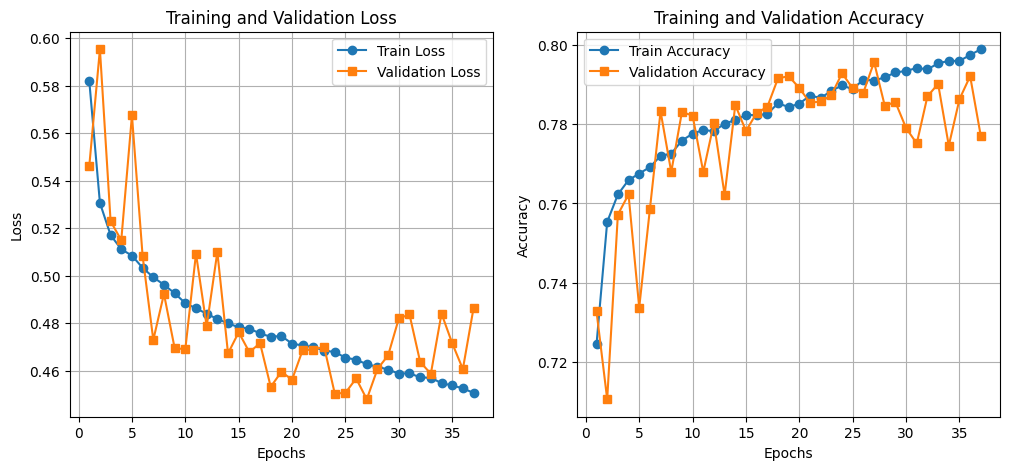

In [14]:
# Vẽ training curve từ history_dict
plot_training_curve(history_dict)

In [11]:
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# seq_shape=(6,29)
# model = LSTMAttentionModel(seq_shape=seq_shape)

# model.train(X_train, y_train, epochs=50, batch_size=32, patience=10)

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# Convert Probabilities to Binary Predictions
y_probs = model.predict(X_test)

y_pred = (y_probs > 0.5).astype(int)

# Compute Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_probs)

print(f"Metrics: Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}, AUC={auc_score:.4f}\n")

487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Metrics: Acc=0.7972, Prec=0.7909, Rec=0.8987, F1=0.8413, AUC=0.8577



In [17]:
# Đảm bảo rằng dữ liệu đầu vào được preprocess đúng cách
X_seq_test = model.preprocess_data(X_test)

# Trích xuất attention values
model_output = model.model.get_layer("attention_layer").output
partial_extraction = Model(inputs=model.model.input, outputs=model_output)
attention_values = np.array(partial_extraction(X_seq_test))


/usr/local/lib/python3.10/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'permute_1' (of type Permute) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [18]:
X_train.columns

Index(['BidsPortfolioManager', 'BidsApi', 'BidsManual', 'UserName',
       'NewCreditCustomer', 'Age', 'Gender', 'AppliedAmount', 'Amount',
       'Interest', 'LoanDuration', 'MonthlyPayment', 'Education',
       'EmploymentStatus', 'IncomeTotal', 'ExistingLiabilities',
       'LiabilitiesTotal', 'RefinanceLiabilities', 'DebtToIncome', 'FreeCash',
       'MonthlyPaymentDay', 'Restructured', 'NoOfPreviousLoansBeforeLoan',
       'AmountOfPreviousLoansBeforeLoan',
       'PreviousEarlyRepaymentsCountBeforeLoan', 'MaturityDifference',
       'LastMaturity_LastPaymentOn', 'LastMaturity_FirstPaymentDate',
       'Rating_Encoded', 'Dayssincepreviousloan'],
      dtype='object')

In [19]:
attention_values.shape

(15583, 6, 29)

In [20]:
columns=X_train.columns
columns

Index(['BidsPortfolioManager', 'BidsApi', 'BidsManual', 'UserName',
       'NewCreditCustomer', 'Age', 'Gender', 'AppliedAmount', 'Amount',
       'Interest', 'LoanDuration', 'MonthlyPayment', 'Education',
       'EmploymentStatus', 'IncomeTotal', 'ExistingLiabilities',
       'LiabilitiesTotal', 'RefinanceLiabilities', 'DebtToIncome', 'FreeCash',
       'MonthlyPaymentDay', 'Restructured', 'NoOfPreviousLoansBeforeLoan',
       'AmountOfPreviousLoansBeforeLoan',
       'PreviousEarlyRepaymentsCountBeforeLoan', 'MaturityDifference',
       'LastMaturity_LastPaymentOn', 'LastMaturity_FirstPaymentDate',
       'Rating_Encoded', 'Dayssincepreviousloan'],
      dtype='object')

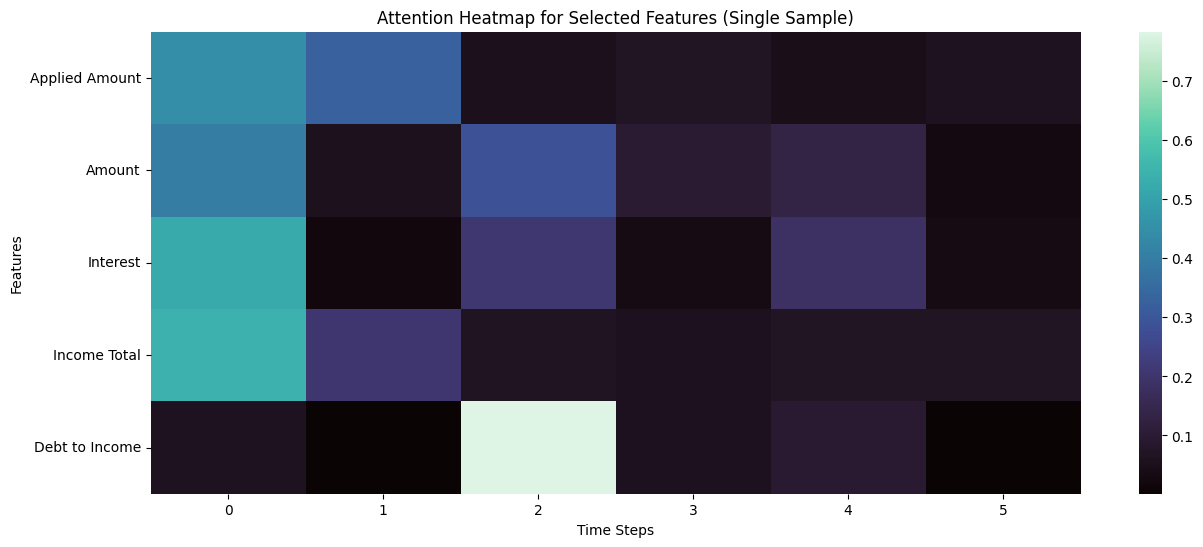

In [27]:
# Chọn index mẫu muốn visualize (ví dụ mẫu đầu tiên)
sample_index = 115
selected_features_indices = [7, 8, 9, 14, 18]
# Lấy attention của mẫu này với các đặc trưng đã chọn
attention_sample = attention_values[sample_index][:, selected_features_indices].T

# Visualize heatmap (features x time_steps)
import matplotlib.pyplot as plt
import seaborn as sns

f, ax = plt.subplots(figsize=(15, 6))
y_axis_labels = ['Applied Amount', 'Amount', 'Interest', 'Income Total', 'Debt to Income']
sns.heatmap(attention_sample, yticklabels=y_axis_labels, cmap="mako")
plt.xlabel('Time Steps')
plt.ylabel('Features')
plt.title('Attention Heatmap for Selected Features (Single Sample)')
plt.show()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'permute_1' (of type Permute) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


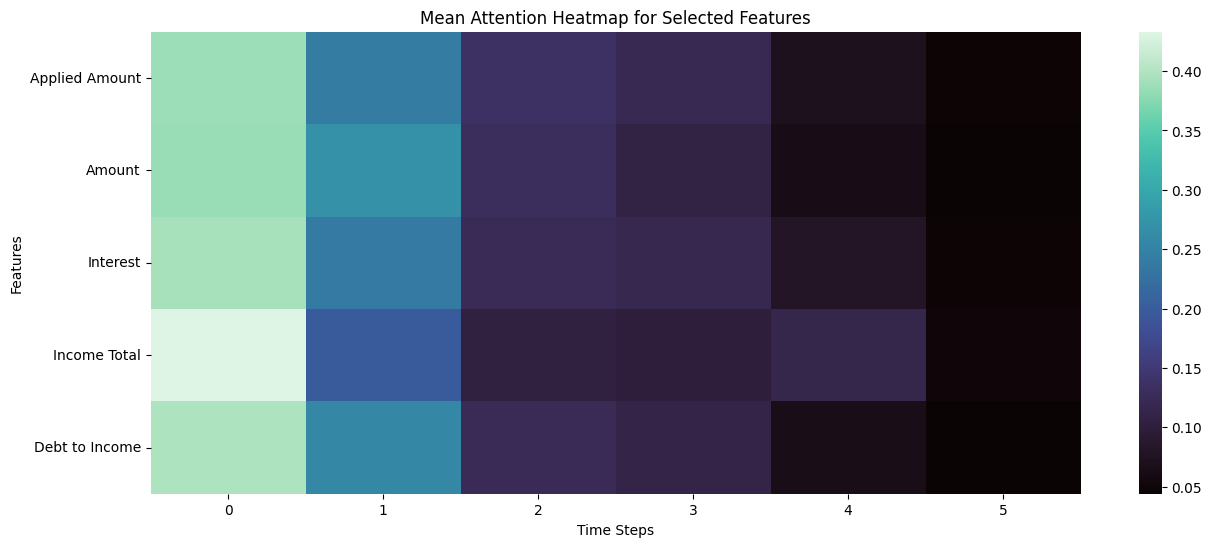

In [28]:
# Preprocess test data
X_seq_test = model.preprocess_data(X_test)

# Extract attention values from the attention layer
model_output = model.model.get_layer("attention_layer").output
partial_extraction = Model(inputs=model.model.input, outputs=model_output)
attention_values = np.array(partial_extraction(X_seq_test))

# Select representative features for visualization
selected_features_indices = [7, 8, 9, 14, 18]  # AppliedAmount, Amount, Interest, IncomeTotal, DebtToIncome

# Compute mean attention values across first 100 samples
attention_mean_100 = attention_values[:, :, :][:, :, selected_features_indices].mean(axis=0).T


f, ax = plt.subplots(figsize=(15, 6))
y_axis_labels = ['Applied Amount', 'Amount', 'Interest', 'Income Total', 'Debt to Income']
sns.heatmap(attention_mean_100, yticklabels=y_axis_labels, cmap="mako")
plt.xlabel('Time Steps')
plt.ylabel('Features')
plt.title('Mean Attention Heatmap for Selected Features')
plt.show()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/layer.py:934: UserWarning: Layer 'permute_1' (of type Permute) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


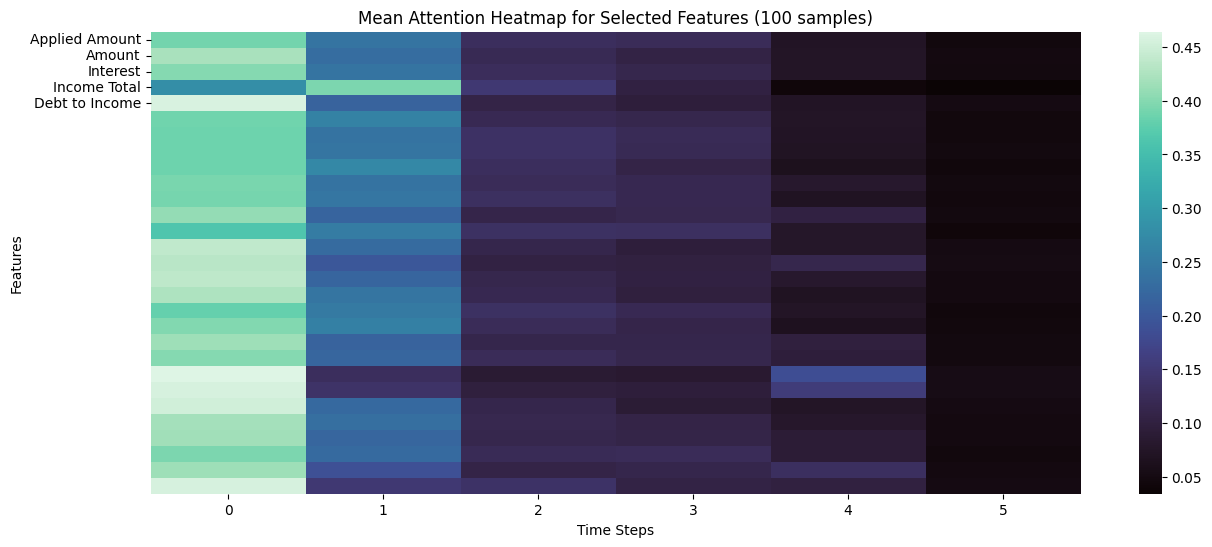

In [23]:
# Preprocess test data
X_seq_test = model.preprocess_data(X_test)

# Extract attention values from the attention layer
model_output = model.model.get_layer("attention_layer").output
partial_extraction = Model(inputs=model.model.input, outputs=model_output)
attention_values = np.array(partial_extraction(X_seq_test))


# Compute mean attention values across first 100 samples
attention_mean_100 = attention_values[:, :, :][:, :, :].mean(axis=0).T


f, ax = plt.subplots(figsize=(15, 6))
y_axis_labels = ['Applied Amount', 'Amount', 'Interest', 'Income Total', 'Debt to Income']
sns.heatmap(attention_mean_100, yticklabels=y_axis_labels, cmap="mako")
plt.xlabel('Time Steps')
plt.ylabel('Features')
plt.title('Mean Attention Heatmap for Selected Features (100 samples)')
plt.show()
